In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_style("whitegrid")

**TASK 1**

*SCENARIO A*


response bias might be occured. in some cases, unsatisfied users less likely to rate the app. if unsatisfied users won't rate, then satisfied users rates won't represent all the users satisfaction. product team can check ratio of download or uninstall with count of rates  

*SCENARIO B*

survivorship bias. School did not studied unsuccessful startups, so all their predictions foundation is successful startups, which might be misleading. They have to check unsuccessful startups and how many of them used pivot in their first two years.

*SCENARIO C*

non-response bias. Unhealty or non-exercising people might not wanted to respond to the mails. 5000 responds means 45000 unresponded mails, which is a very bit portion. And,likely, big part of this portion is not doing exercises or something. platform should send another survey to this 45000 people with another, simpler and shorter questions so users will take time and answer it, and according these answers they will compare results with previous survey

*SCENARIO D*

Measurement bias. Self-reported incomes are tend to be larger than they are. In large cities, salary band is larger than small cities and if submitters of this survey are from big cities, small city companies which uses this data will, most likely, lose a lot of money in a matter of salaries and long term they will bankcrupt. companies filter the results in order to find similar cities average salaries to use

**TASK 2**

In [ ]:
N = 100_000

age_raw = np.random.normal(loc=40, scale=15, size=N)
age = np.clip(age_raw, 18, 85).astype(int)

income_noise = np.random.normal(loc=0, scale=25000, size=N)
income_raw = (1500 * age) + income_noise
income = np.clip(income_raw, 15000, 250000)

satisfaction_noise = np.random.normal(loc=0, scale=1.5, size=N)
satisfaction_raw = 4 + (income / 50000) + satisfaction_noise
satisfaction = np.clip(np.round(satisfaction_raw), 1, 10).astype(int)

regions = ["Urban", "Suburban", "Rural"]
probabilities = [0.60, 0.25, 0.15]
region = np.random.choice(regions, size=N, p=probabilities)

population_df = pd.DataFrame({
    'age': age,
    'income': income,
    'satisfaction': satisfaction,
    'region': region
})

true_mean_age = population_df['age'].mean()
true_mean_income = population_df['income'].mean()
true_mean_satisfaction = population_df['satisfaction'].mean()
true_region_props = population_df['region'].value_counts(normalize=True)

print("--- TRUE POPULATION PARAMETERS (GROUND TRUTH) ---")
print(f"Population Size:  {len(population_df):,}")
print(f"Mean Age:         {true_mean_age:.2f} years")
print(f"Mean Income:      ${true_mean_income:,.2f}")
print(f"Mean Sat. Score:  {true_mean_satisfaction:.2f} / 10\n")

print("Region Proportions:")
for reg, prop in true_region_props.items():
    print(f"  - {reg}: {prop:.2%}")
    
print("\n--- POPULATION DATAFRAME HEAD ---")
print(population_df.head())

--- TRUE POPULATION PARAMETERS (GROUND TRUTH) ---
Population Size:  100,000
Mean Age:         40.02 years
Mean Income:      $61,212.18
Mean Sat. Score:  5.22 / 10

Region Proportions:
  - Urban: 59.93%
  - Suburban: 25.07%
  - Rural: 15.00%

--- POPULATION DATAFRAME HEAD ---
   age        income  satisfaction    region
0   47  96264.864700             8  Suburban
1   37  26616.130824             4     Urban
2   49  87885.929756             4     Urban
3   62  77519.038546             3     Urban
4   36  45814.929841             4     Rural


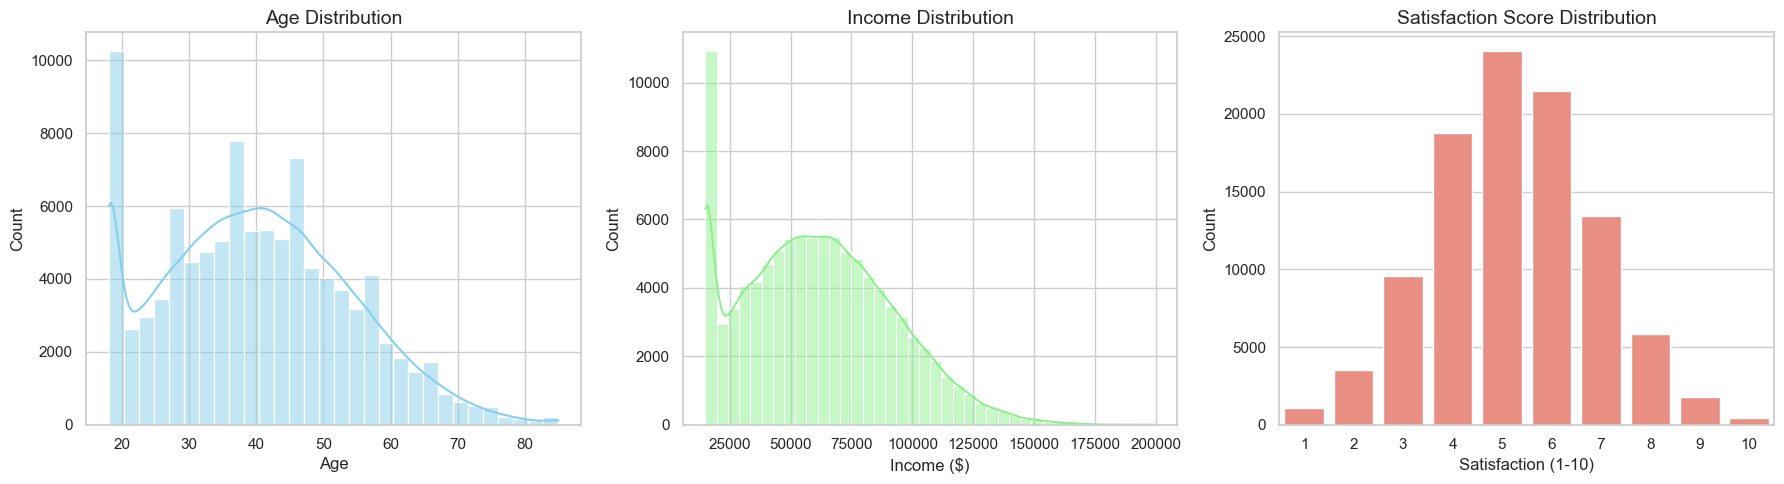

In [ ]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(population_df['age'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Age Distribution', fontsize=14)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sns.histplot(population_df['income'], bins=40, kde=True, color='lightgreen', ax=axes[1])
axes[1].set_title('Income Distribution', fontsize=14)
axes[1].set_xlabel('Income ($)')
axes[1].set_ylabel('Count')

sns.countplot(data=population_df, x='satisfaction', color='salmon', ax=axes[2])
axes[2].set_title('Satisfaction Score Distribution', fontsize=14)
axes[2].set_xlabel('Satisfaction (1-10)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

--- SAMPLE VS POPULATION COMPARISON ---
           Metric True Population SRS (n=200) Urban Only (n=200) High Income (n=200)
         Mean Age           40.02       41.25              38.20               46.60
      Mean Income       61,212.18   60,424.91          55,578.38           84,631.20
Mean Satisfaction            5.22        5.12               5.41                5.58
           Metric True Population SRS (n=200) Urban Only (n=200) High Income (n=200)
         Mean Age           40.02       41.25              38.20               46.60
      Mean Income       61,212.18   60,424.91          55,578.38           84,631.20
Mean Satisfaction            5.22        5.12               5.41                5.58


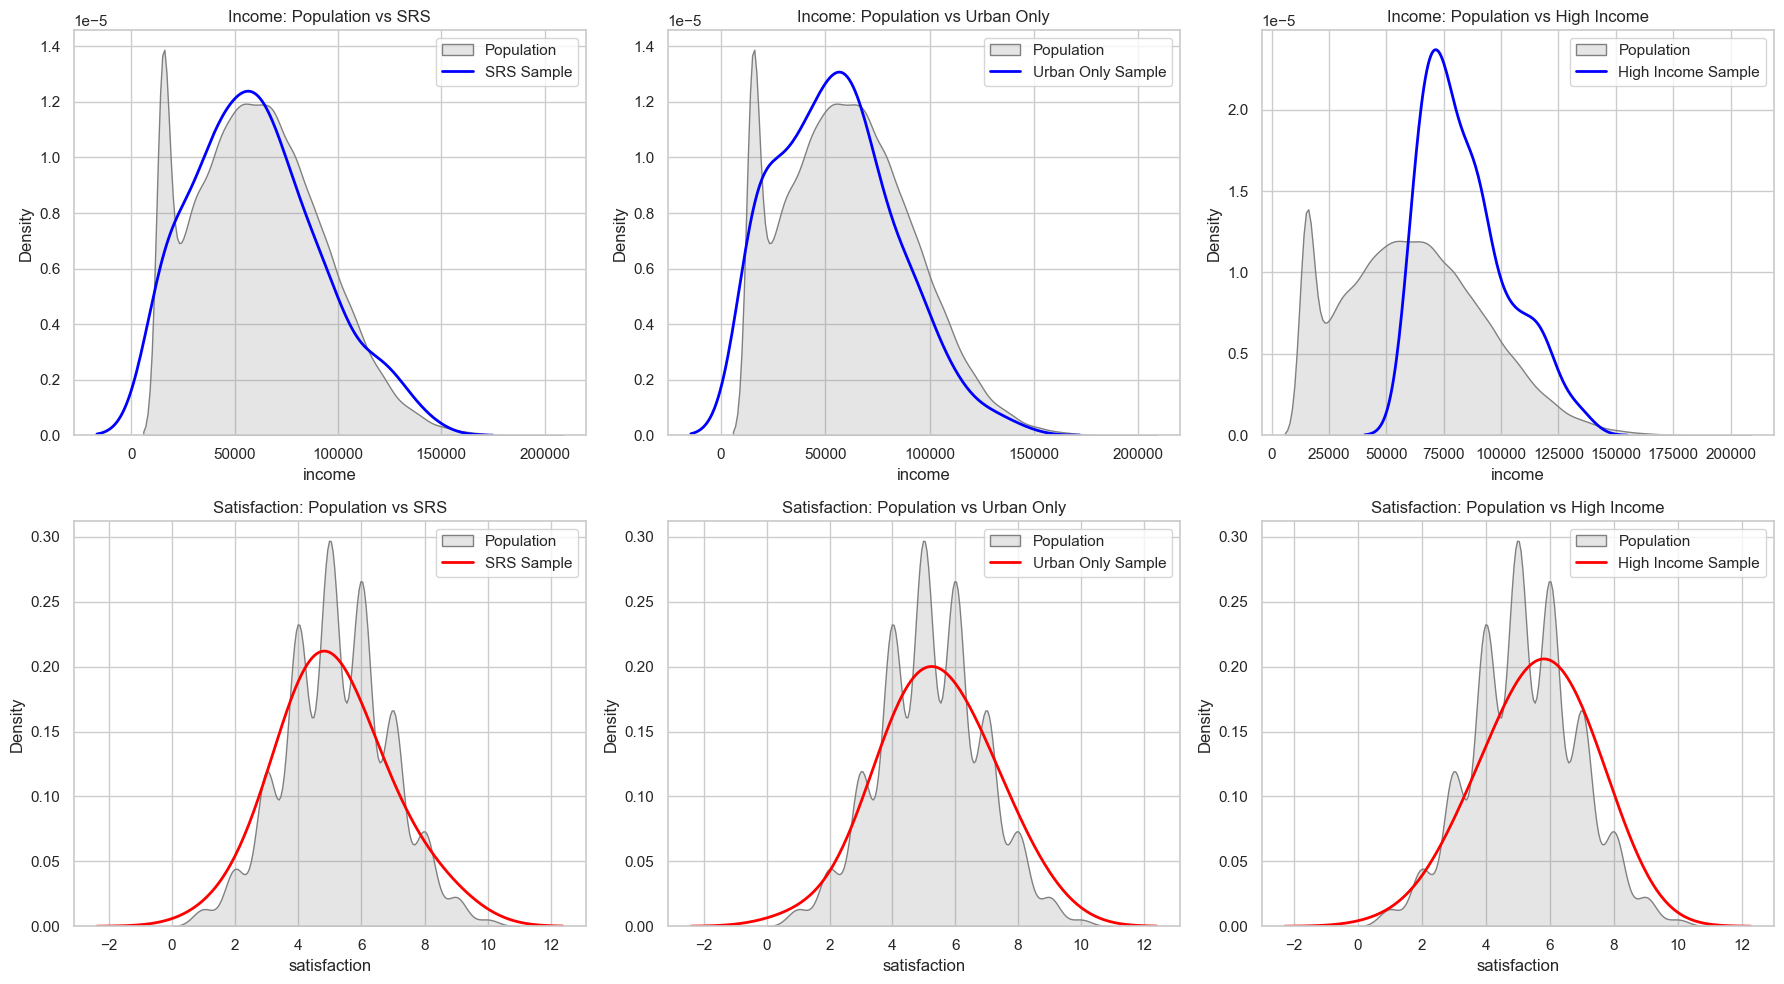

In [ ]:
n_sample = 200

srs_sample = population_df.sample(n=n_sample, random_state=101)

urban_sample = population_df[population_df['region'] == 'Urban'].sample(n=n_sample, random_state=101)

median_income = population_df['income'].median()
high_income_sample = population_df[population_df['income'] > median_income].sample(n=n_sample, random_state=101)

comparison_data = {
    'Metric': ['Mean Age', 'Mean Income', 'Mean Satisfaction'],
    'True Population': [true_mean_age, true_mean_income, true_mean_satisfaction],
    'SRS (n=200)': [srs_sample['age'].mean(), srs_sample['income'].mean(), srs_sample['satisfaction'].mean()],
    'Urban Only (n=200)': [urban_sample['age'].mean(), urban_sample['income'].mean(), urban_sample['satisfaction'].mean()],
    'High Income (n=200)': [high_income_sample['age'].mean(), high_income_sample['income'].mean(), high_income_sample['satisfaction'].mean()]
}

comparison_df = pd.DataFrame(comparison_data)

format_dict = {
    'True Population': lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else x,
    'SRS (n=200)': lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else x, 
    'Urban Only (n=200)': lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else x, 
    'High Income (n=200)': lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else x
}

print(comparison_df.to_string(formatters=format_dict, index=False))
-
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.set_theme(style="whitegrid")

samples = [('SRS', srs_sample), ('Urban Only', urban_sample), ('High Income', high_income_sample)]

for i, (name, sample_df) in enumerate(samples):
    sns.kdeplot(data=population_df, x='income', color='grey', fill=True, alpha=0.2, label='Population', ax=axes[0, i])
    sns.kdeplot(data=sample_df, x='income', color='blue', linewidth=2, label=f'{name} Sample', ax=axes[0, i])
    axes[0, i].set_title(f'Income: Population vs {name}')
    axes[0, i].legend()

    sns.kdeplot(data=population_df, x='satisfaction', color='grey', fill=True, alpha=0.2, label='Population', ax=axes[1, i], bw_adjust=2)
    sns.kdeplot(data=sample_df, x='satisfaction', color='red', linewidth=2, label=f'{name} Sample', ax=axes[1, i], bw_adjust=2)
    axes[1, i].set_title(f'Satisfaction: Population vs {name}')
    axes[1, i].legend()

plt.tight_layout()
plt.show()

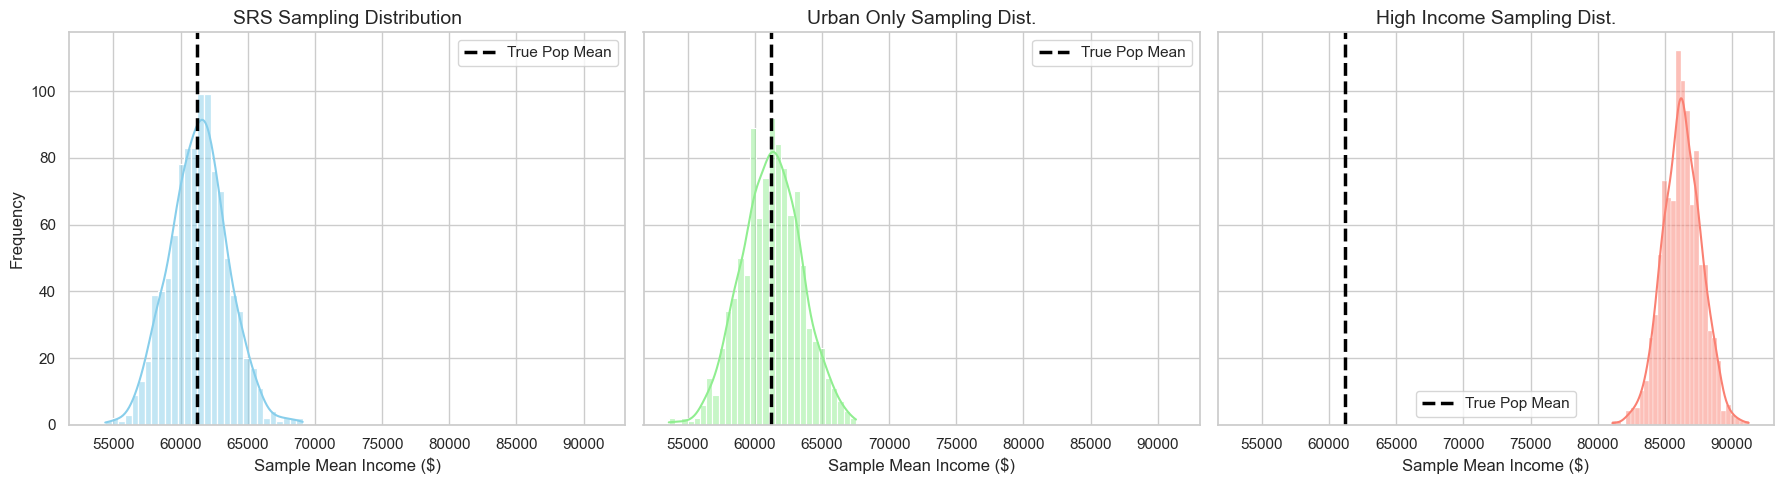

In [ ]:
iterations = 1000
srs_means = []
urban_means = []
high_income_means = []

urban_pop = population_df[population_df['region'] == 'Urban']
high_inc_pop = population_df[population_df['income'] > median_income]

for _ in range(iterations):
    srs_means.append(population_df.sample(n=n_sample)['income'].mean())
    urban_means.append(urban_pop.sample(n=n_sample)['income'].mean())
    high_income_means.append(high_inc_pop.sample(n=n_sample)['income'].mean())

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, sharex=True)

distributions = [
    (srs_means, 'SRS Sampling Distribution', 'skyblue'),
    (urban_means, 'Urban Only Sampling Dist.', 'lightgreen'),
    (high_income_means, 'High Income Sampling Dist.', 'salmon')
]

for i, (data, title, color) in enumerate(distributions):
    sns.histplot(data, bins=30, kde=True, color=color, ax=axes[i])
    axes[i].axvline(true_mean_income, color='black', linestyle='--', linewidth=2.5, label='True Pop Mean')
    axes[i].set_title(title, fontsize=14)
    axes[i].set_xlabel('Sample Mean Income ($)')
    axes[i].legend()

axes[0].set_ylabel('Frequency')
plt.tight_layout()
plt.show()